<a href="https://colab.research.google.com/github/pactiones/Treinamento-em-IA/blob/main/Aula3/Exercicio_2_Dataset_CSV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd "/content/drive/MyDrive/Atividade 2 - Titanic"

/content/drive/MyDrive/Atividade 2 - Titanic


#Atividade Titanic - Mateus Pactiones

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df_titanic = pd.read_csv(url)

In [4]:
print("Primeiras linhas")
print(df_titanic.head())

print("\n")
print("Quantidade de linhas e colunas")
print(df_titanic.shape)

print("\n")
print("Nomes das colunas")
print(df_titanic.columns.tolist())

print("\n")
print("Informações gerais:")
print(df_titanic.info())

Primeiras linhas
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

In [5]:
print("Valores ausentes por coluna:")
print(df_titanic.isnull().sum())

Valores ausentes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
porcentagem_ausentes = (
    df_titanic.isnull().sum() / len(df_titanic) * 100
)

print("Valores ausentes (em %): ")
print(porcentagem_ausentes.round(2))

Valores ausentes (em %): 
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [7]:
print("Quantidade de linhas duplicadas: ")
print(df_titanic.duplicated().sum())

Quantidade de linhas duplicadas: 
0


In [8]:
display(df_titanic.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("Contagem de sobreviventes: ")
print(df_titanic["Survived"].value_counts())

Contagem de sobreviventes: 
Survived
0    549
1    342
Name: count, dtype: int64


In [10]:
sobrevivencia_sexo = (
    df_titanic.groupby("Sex")["Survived"].mean() * 100
)
sobrevivencia_classe = (
    df_titanic.groupby("Pclass")["Survived"].mean() * 100
)

print("Taxa de sobrevivencia por sexo (em %): ")
display(sobrevivencia_sexo.round(2))

print("Taxa de sobrevivencia por classe (em %): ")
display(sobrevivencia_classe.round(2))

Taxa de sobrevivencia por sexo (em %): 


,Survived
Sex,
female,74.20
male,18.89


Taxa de sobrevivencia por classe (em %): 


,Survived
Pclass,
1,62.96
2,47.28
3,24.24


In [11]:
df_tratado = df_titanic.copy()

#Tratamento de valores ausentes


###Tratamento da coluna age

A coluna Age possui 177 valores ausentes, o equivalente a aproximadamente 19,87%.

Não é possivel descobrir a idade real dos passageiros. Entretanto, é possível fazer uma média das idades baseado nos valores já preenchidos. Por isso, os valores ausentes serão preenchidos com a mediana das idades conhecidas.

Os valores preenchidos são estimativas e não devem ser interpretados como as idades verdadeiras.

In [12]:
mediana = df_tratado["Age"].median()

print("Mediana das idades: ")
print(mediana)

df_tratado["Age"] = df_tratado["Age"].fillna(mediana)

print("\n")
print("Valores ausentes após o tratamento: ")
print(df_tratado["Age"].isnull().sum)

Mediana das idades: 
28.0


Valores ausentes após o tratamento: 
<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Age, Length: 891, dtype: bool>


###Tratamento da coluna Cabin

A coluna Cabin possui 687 valores ausentes, correspondendo a aproximadamente 77,10% do dataset.

Como são muitas cabines, e não é possível descobrir a cabine real de cada passageiro. Os valores ausentes serão substituídos pela categoria "Desconhecida".

In [13]:
df_tratado["Cabin"] = df_tratado["Cabin"].fillna("Desconhecida")

print("Valores ausentes após o tratamento: ")
print(df_tratado["Cabin"].isnull().sum())

print("\n")
print("Valores mais frequentes em Cabin: ")
print(df_tratado["Cabin"].value_counts().head)

Valores ausentes após o tratamento: 
0


Valores mais frequentes em Cabin: 
<bound method NDFrame.head of Cabin
Desconhecida    687
G6                4
C23 C25 C27       4
B96 B98           4
F2                3
               ... 
E17               1
A24               1
C50               1
B42               1
C148              1
Name: count, Length: 148, dtype: int64>


###Tratamento da coluna Embarked

A coluna Embarked possui somente 2 valores ausentes, correspondendo a 0,22% do dataset.

Os valores ausentes serão preenchidos com a moda. Logo, o ponto de embarque que aparece com maior frequência, será o valor para ser substituído.

In [14]:
moda = df_tratado["Embarked"].mode()[0]

print("Porto de embarque mais frequente: ")
print(moda)

df_tratado["Embarked"] = df_tratado["Embarked"].fillna(moda)

print("\n")
print(df_tratado["Embarked"].isnull().sum())

Porto de embarque mais frequente: 
S


0


###Verificação final

Após a alteração dos valores, será verificado se ainda existem valores ausentes no dataframe.

In [15]:
print("Valores ausentes no dataframe original: ")
print(df_titanic.isnull().sum())

print("\n")
print("Valores ausentes no dataframe tratado: ")
print(df_tratado.isnull().sum())

print("\n")
print("Total de valores ausentes após o tratamento: ")
print(df_tratado.isnull().sum().sum())

Valores ausentes no dataframe original: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Valores ausentes no dataframe tratado: 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Total de valores ausentes após o tratamento: 
0


Após o tratamento, deixaram de existir quaisquer tipos de valores ausentes.

Gráfico de barras


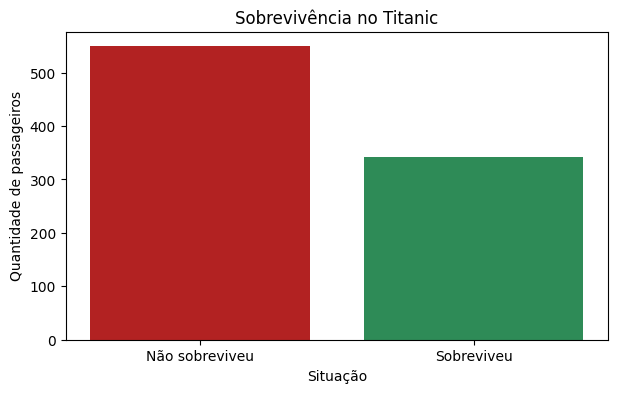

In [16]:
print("Gráfico de barras")

contagem_sobrevivencia = (
    df_titanic["Survived"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))

plt.bar(
    ["Não sobreviveu", "Sobreviveu"],
    contagem_sobrevivencia.values,
    color=["firebrick", "seagreen"]
)

plt.xlabel("Situação")
plt.ylabel("Quantidade de passageiros")
plt.title("Sobrevivência no Titanic")

plt.show()

Gráfico de histograma


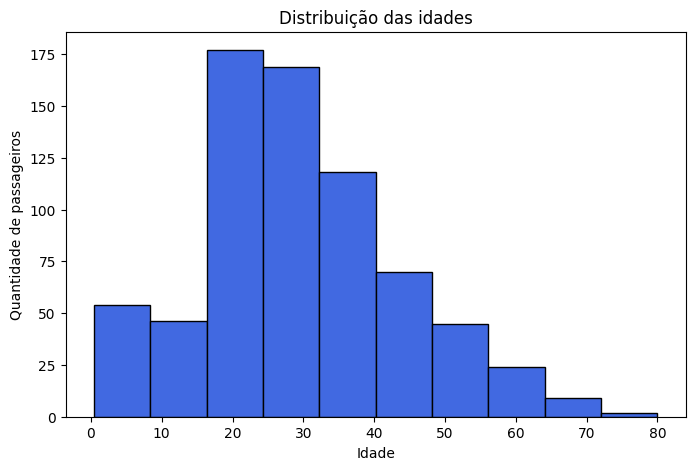

In [17]:
print("Gráfico de histograma")

plt.figure(figsize=(8, 5))

plt.hist(
    df_titanic["Age"],
    color="royalblue",
    edgecolor="black"
)

plt.xlabel("Idade")
plt.ylabel("Quantidade de passageiros")
plt.title("Distribuição das idades")

plt.show()

Gráfico de dispersão


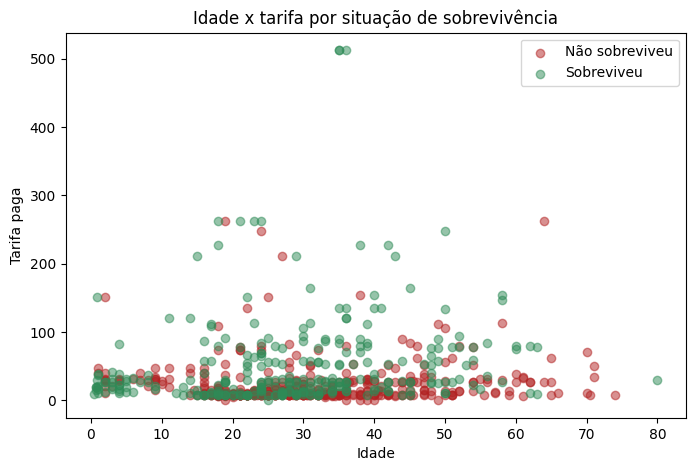

In [18]:
print("Gráfico de dispersão")

cores = {
    0: "firebrick",
    1: "seagreen"
}

rotulos = {
    0: "Não sobreviveu",
    1: "Sobreviveu"
}

plt.figure(figsize=(8, 5))

for situacao in [0, 1]:
    dados = df_titanic[df_titanic["Survived"] == situacao]

    plt.scatter(
        dados["Age"],
        dados["Fare"],
        color=cores[situacao],
        label=rotulos[situacao],
        alpha=0.5
    )

plt.xlabel("Idade")
plt.ylabel("Tarifa paga")
plt.title("Idade x tarifa por situação de sobrevivência")
plt.legend()

plt.show()

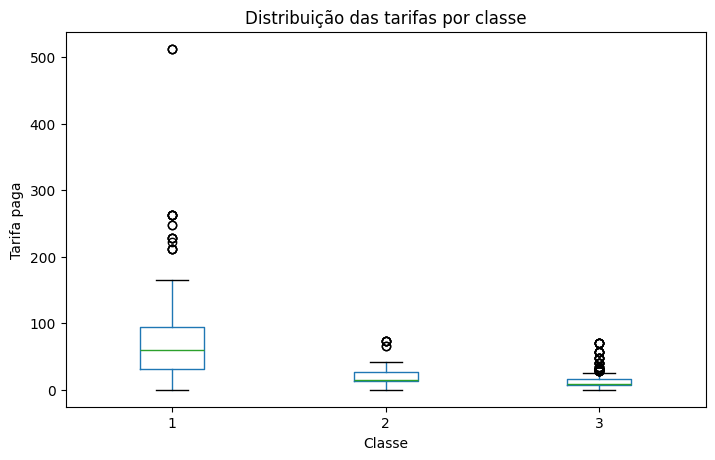

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

df_titanic.boxplot(
    column="Fare",
    by="Pclass",
    grid=False,
    ax=ax
)

ax.set_xlabel("Classe")
ax.set_ylabel("Tarifa paga")
ax.set_title("Distribuição das tarifas por classe")

plt.suptitle("")
plt.show()

In [20]:
colunas_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlacao = df_titanic[colunas_numericas].corr()

print("Correlação entre as variáveis:")
print(correlacao.round(2))

Correlação entre as variáveis:
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00


##Insights da análise

1. O dataset possui 891 passageiros. Desses, 342 sobreviveram e 549 não sobreviveram, indicando que a maioria dos passageiros não sobreviveu ao naufrágio.

2. A taxa de sobrevivência das mulheres foi de aproximadamente 74,20%, enquanto a taxa dos homens foi de aproximadamente 18,89%. Portanto, o sexo apresentou uma forte relação com a sobrevivência.

3. Passageiros da primeira classe tiveram uma taxa de sobrevivência de aproximadamente 62,96%. Na terceira classe, essa taxa foi de aproximadamente 24,24%. Isso indica que a classe do passageiro também esteve relacionada à sobrevivência.

4. A coluna Cabin possui aproximadamente 77,10% de valores ausentes, sendo a coluna com maior problema de preenchimento. A coluna Age possui aproximadamente 19,87% de valores ausentes e pode ser tratada com o preenchimento pela mediana.

5. Passageiros da primeira classe geralmente pagaram tarifas maiores. A correlação também indica uma relação positiva entre a tarifa paga e a sobrevivência, embora essa relação não signifique necessariamente que a tarifa, sozinha, tenha causado a sobrevivência.